# MobileNet-SSDv3 — Cacao Bean Detection Experiment

**Experiment 2 of 3** (independent, non-comparative in this notebook): `YOLOv11n`, `MobileNet-SSDv3`, `EfficientDet-Lite0`.
This notebook trains and evaluates **only MobileNet-SSDv3**. No other model is trained or compared here.

### Implementation note
"MobileNet-SSDv3" does not correspond to a single, unambiguous, actively-maintained package. The closest technically valid, currently-supported implementation is **torchvision's `ssdlite320_mobilenet_v3_large`** — an SSD (Single Shot Detector) head combined with a MobileNetV3-Large backbone, i.e. exactly "MobileNet + SSD + v3". This is the implementation used throughout this notebook (`torchvision.models.detection.ssdlite320_mobilenet_v3_large`).

**Dataset:** `Cacao_Bean_Detection_Trial_01_v12-d800-70-20-10_coco.zip` (Roboflow COCO export, 800 images, classes: `Broken`, `Cluster`, `Flat`, `Normal`).

**Fixed cross-experiment protocol:**
| Setting | Value |
|---|---|
| Random seed | 42 |
| Split | 80% train / 10% val / 10% test |
| Standardized resolution target | 640×640 (see §2 note on this framework's native input size) |
| Epochs | 50 |
| Batch size | 16 |
| Confidence threshold | 0.25 |
| IoU threshold | 0.50 |

Run cells top-to-bottom on a **Google Colab GPU runtime** (Runtime → Change runtime type → GPU), the same runtime type used for the YOLOv11n and EfficientDet-Lite0 notebooks.


## 1. Environment Verification

In [ ]:
import sys, platform

try:
    import torch
except ImportError:
    raise SystemExit("PyTorch is not available in this runtime. Use a standard Google Colab runtime.")

gpu_available = torch.cuda.is_available()
print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {gpu_available}")

if not gpu_available:
    raise SystemExit(
        "\n\n*** NO GPU DETECTED ***\n"
        "This notebook requires a GPU runtime.\n"
        "Go to: Runtime -> Change runtime type -> Hardware accelerator -> GPU, then re-run.\n"
    )

gpu_name = torch.cuda.get_device_name(0)
cuda_version = torch.version.cuda
print(f"GPU name       : {gpu_name}")
print(f"CUDA version   : {cuda_version}")
print("\nGPU check passed. Continuing.")


Python version : 3.13.15
PyTorch version: 2.11.0+cu128
CUDA available : True
GPU name       : Tesla T4
CUDA version   : 12.8

GPU check passed. Continuing.


## 2. Install Dependencies

In [ ]:
%%capture
!pip install -q torchvision torchmetrics pycocotools scikit-learn fvcore


In [ ]:
import torchvision
print(f"torchvision version: {torchvision.__version__}")
import torchmetrics
print(f"torchmetrics version: {torchmetrics.__version__}")


torchvision version: 0.26.0+cu128
torchmetrics version: 1.9.0


### Note on the 640×640 requirement

`ssdlite320_mobilenet_v3_large` is architecturally built around a **320×320** input: its pretrained anchor boxes, feature-map strides, and image-mean/std normalization are all defined relative to a 320×320 resize performed internally by the model's own `GeneralizedRCNNTransform`. Forcing a different fixed resolution requires re-deriving the anchor configuration and discards the ImageNet-pretrained-backbone benefits the fixed 320 scale is tuned for.

Per the task instructions ("use 640×640 whenever technically supported ... document any framework-specific preprocessing"), this notebook therefore keeps the model at its native, technically supported **320×320** input resolution. Original images are still uploaded and stored at their native size (no permanent resize to disk); the 320×320 resize happens only inside the model's forward pass, and bounding boxes are rescaled consistently by the same internal transform. This is documented again in the reproducibility record (§16).

## 3. Imports, Global Seed, and Reproducibility Setup

In [ ]:
import os, sys, json, glob, shutil, random, time, zipfile, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageDraw

from sklearn.model_selection import train_test_split

SEED = 42

def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_global_seed(SEED)
print(f"Global random seed fixed at {SEED} (python, numpy, torch, PYTHONHASHSEED).")

device = torch.device("cuda:0")

WORK_DIR = Path("/content/cacao_mobilenetssdv3")
WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)
print(f"Working directory: {WORK_DIR}")


Global random seed fixed at 42 (python, numpy, torch, PYTHONHASHSEED).
Working directory: /content/cacao_mobilenetssdv3


## 4. Dataset Upload

Upload the COCO-format dataset ZIP (e.g. `Cacao_Bean_Detection_Trial_01_v12-d800-70-20-10_coco.zip`).

Optional: upload the `dataset_split_seed42.json` manifest saved by the YOLOv11n notebook to force the **exact same** train/val/test assignment across all three experiments. If omitted, this notebook reruns the identical seed-42 stratified split algorithm and will reproduce the same split as long as the same dataset ZIP is used.

In [ ]:
from google.colab import files

print("Select the dataset ZIP file (and optionally dataset_split_seed42.json).")
uploaded = files.upload()

zip_candidates = [f for f in uploaded if f.lower().endswith(".zip")]
json_candidates = [f for f in uploaded if f.lower().endswith(".json")]

if not zip_candidates:
    raise SystemExit("No .zip file was uploaded. Please re-run this cell and upload the COCO dataset ZIP.")

DATASET_ZIP = zip_candidates[0]
EXTERNAL_SPLIT_MANIFEST = json_candidates[0] if json_candidates else None
print(f"Dataset ZIP: {DATASET_ZIP}")
print(f"External split manifest: {EXTERNAL_SPLIT_MANIFEST}")


Select the dataset ZIP file (and optionally dataset_split_seed42.json).


Saving Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip to Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip
Dataset ZIP: Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip
External split manifest: None


In [ ]:
RAW_DIR = WORK_DIR / "dataset_raw"
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
RAW_DIR.mkdir(parents=True)

with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
    zf.extractall(RAW_DIR)

print(f"Extracted to: {RAW_DIR}")
for p in sorted(RAW_DIR.rglob("*"))[:20]:
    print(" ", p.relative_to(RAW_DIR))
n_files = sum(1 for _ in RAW_DIR.rglob("*") if _.is_file())
print(f"... ({n_files} files total)")


Extracted to: /content/cacao_mobilenetssdv3/dataset_raw
  README.dataset.txt
  README.roboflow.txt
  test
  test/M4_FR_NormFlatBrokClus-18-_jpg.rf.1e619eaa40f06517f8ed04b938370d77.jpg
  test/M4_FR_NormFlatBrokClus-19-_jpg.rf.6bed7f5ace84eb717edca9597ef0c685.jpg
  test/M4_FR_NormFlatBrokClus-2-_jpg.rf.43066e4fd13db17d68e106b0897254e1.jpg
  test/M4_FR_NormFlatBrokClus-22-_jpg.rf.d813239010e600102efb2a9149b76205.jpg
  test/M4_FR_NormFlatBrokClus-39-_jpg.rf.81e2cad8787f668f940ab31f80987b2d.jpg
  test/M4_FR_NormFlatBrokClus-49-_jpg.rf.70698b7810276afc0065fde07a8cba58.jpg
  test/M4_FR_NormFlatBrokClus-55-_jpg.rf.0e79d4c7fa393c1865c9827bee0cf686.jpg
  test/M4_FR_NormFlatBrokClus-56-_jpg.rf.84e645f3d49da7fc0e7a34d2b2f6cac4.jpg
  test/M4_FR_NormFlatBrokClus-61-_jpg.rf.054a56de2d6d51b0e40f4a1aa7a7210d.jpg
  test/M4_FR_NormFlatBrokClus-65-_jpg.rf.c6e5a18ade94a88809b953eba0f2632b.jpg
  test/M4_FR_NormFlatBrokClus-7-_jpg.rf.08ee969d056dd9740eb2afe072144353.jpg
  test/M4_FR_NormFlatBrokClus-70-_jpg.

## 5. Locate and Validate COCO Annotations

Uses the same discovery/validation procedure as the YOLOv11n notebook so both experiments start from an identical, verified image pool.

In [ ]:
def find_coco_json_files(root: Path):
    # Find every JSON file under root that looks like a COCO annotation file.
    found = []
    for jp in root.rglob("*.json"):
        try:
            with open(jp, "r") as f:
                d = json.load(f)
        except Exception:
            continue
        if isinstance(d, dict) and {"images", "annotations", "categories"} <= set(d.keys()):
            found.append(jp)
    return found

coco_json_files = find_coco_json_files(RAW_DIR)
if not coco_json_files:
    raise SystemExit("No COCO-format annotation JSON file was found inside the ZIP.")

print(f"Found {len(coco_json_files)} COCO annotation file(s):")
for jp in coco_json_files:
    print(" -", jp.relative_to(RAW_DIR))


Found 3 COCO annotation file(s):
 - valid/_annotations.coco.json
 - test/_annotations.coco.json
 - train/_annotations.coco.json


In [ ]:
loaded_splits = []
reference_categories = None

for jp in coco_json_files:
    with open(jp, "r") as f:
        d = json.load(f)
    split_name = jp.parent.name.lower()
    split_name = {"valid": "val", "validation": "val"}.get(split_name, split_name)

    cats = sorted(d["categories"], key=lambda c: c["id"])
    if reference_categories is None:
        reference_categories = cats
    else:
        if [c["id"] for c in cats] != [c["id"] for c in reference_categories] or \
           [c["name"] for c in cats] != [c["name"] for c in reference_categories]:
            print(f"WARNING: category set in {jp} differs from the first file encountered.")

    images_by_id = {im["id"]: im for im in d["images"]}
    anns_by_image = defaultdict(list)
    for a in d["annotations"]:
        anns_by_image[a["image_id"]].append(a)

    loaded_splits.append({
        "name": split_name, "dir": jp.parent,
        "images": images_by_id, "anns": anns_by_image,
        "n_images": len(images_by_id), "n_anns": len(d["annotations"]),
    })

print("Categories (from COCO file):")
for c in reference_categories:
    print(f"  id={c['id']:>2}  name={c['name']!r}  supercategory={c.get('supercategory')}")

for s in loaded_splits:
    print(f"\nSplit source '{s['name']}' ({s['dir'].relative_to(RAW_DIR)}): "
          f"{s['n_images']} images, {s['n_anns']} annotations")


Categories (from COCO file):
  id= 0  name='Bean'  supercategory=none
  id= 1  name='Broken'  supercategory=Bean
  id= 2  name='Cluster'  supercategory=Bean
  id= 3  name='Flat'  supercategory=Bean
  id= 4  name='Normal'  supercategory=Bean

Split source 'val' (valid): 200 images, 314 annotations

Split source 'test' (test): 100 images, 182 annotations

Split source 'train' (train): 2100 images, 3315 annotations


In [ ]:
pool = []
missing = []
seen_filenames = set()
dup_filenames = []

for s in loaded_splits:
    for img_id, im in s["images"].items():
        fp = s["dir"] / im["file_name"]
        if not fp.exists():
            missing.append(str(fp))
            continue
        if im["file_name"] in seen_filenames:
            dup_filenames.append(im["file_name"])
        seen_filenames.add(im["file_name"])
        pool.append({
            "file_path": fp, "file_name": im["file_name"],
            "width": im["width"], "height": im["height"],
            "anns": s["anns"].get(img_id, []), "orig_split": s["name"],
        })

print(f"Total image records collected : {len(pool)}")
print(f"Missing image files           : {len(missing)}")
print(f"Duplicate file names          : {len(dup_filenames)}")

assert len(missing) == 0, "Some annotated images are missing from disk. Aborting."
assert len(dup_filenames) == 0, "Duplicate filenames across source folders would collide when merged. Aborting."
print("\nAll images and annotations correspond correctly.")


Total image records collected : 2400
Missing image files           : 0
Duplicate file names          : 0

All images and annotations correspond correctly.


## 6. Dataset Statistics

Category ids actually used in annotations: [1, 2, 3, 4]
   1 -> Broken
   2 -> Cluster
   3 -> Flat
   4 -> Normal
Category id(s) present in metadata but never used as a label: [0] (['Bean']) -- excluded from the model's class list.

Total images        : 2400
Total bounding boxes : 3811
Image size range     : width [640, 640], height [640, 640]


,class_id,class_name,box_count,percent
0,1,Broken,951,24.95
1,2,Cluster,965,25.32
2,3,Flat,949,24.90
3,4,Normal,946,24.82


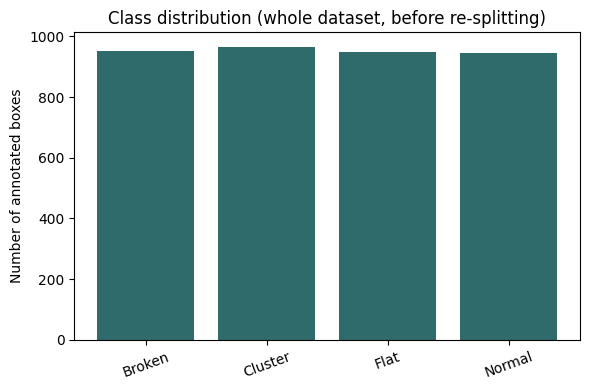

In [ ]:
cat_id_to_name = {c["id"]: c["name"] for c in reference_categories}
used_cat_ids = sorted({a["category_id"] for r in pool for a in r["anns"]})
print("Category ids actually used in annotations:", used_cat_ids)
for cid in used_cat_ids:
    print(f"   {cid} -> {cat_id_to_name[cid]}")
unused = [c["id"] for c in reference_categories if c["id"] not in used_cat_ids]
if unused:
    print(f"Category id(s) present in metadata but never used as a label: {unused} "
          f"({[cat_id_to_name[i] for i in unused]}) -- excluded from the model's class list.")

n_images = len(pool)
n_boxes = sum(len(r["anns"]) for r in pool)
class_counts = Counter(a["category_id"] for r in pool for a in r["anns"])
widths = [r["width"] for r in pool]
heights = [r["height"] for r in pool]

print(f"\nTotal images        : {n_images}")
print(f"Total bounding boxes : {n_boxes}")
print(f"Image size range     : width [{min(widths)}, {max(widths)}], height [{min(heights)}, {max(heights)}]")

stats_df = pd.DataFrame([
    {"class_id": cid, "class_name": cat_id_to_name[cid], "box_count": class_counts.get(cid, 0)}
    for cid in used_cat_ids
])
stats_df["percent"] = (100 * stats_df["box_count"] / stats_df["box_count"].sum()).round(2)
display(stats_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(stats_df["class_name"], stats_df["box_count"], color="#2f6b6b")
ax.set_title("Class distribution (whole dataset, before re-splitting)")
ax.set_ylabel("Number of annotated boxes")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7. Dataset Split (80% / 10% / 10%, seed 42)

Identical procedure to the YOLOv11n notebook: pool every image from the uploaded (70/20/10) export and re-split reproducibly, stratified by class, with seed 42. If a `dataset_split_seed42.json` manifest was uploaded, it is applied directly instead, guaranteeing byte-identical assignment to the other experiments.

In [ ]:
def dominant_label(record):
    # Stratification key: the (single, in this dataset) or most frequent class in the image.
    if not record["anns"]:
        return -1
    counts = Counter(a["category_id"] for a in record["anns"])
    return counts.most_common(1)[0][0]

manifest_path = WORK_DIR / "dataset_split_seed42.json"

if EXTERNAL_SPLIT_MANIFEST is not None:
    with open(EXTERNAL_SPLIT_MANIFEST, "r") as f:
        manifest = json.load(f)
    assign = manifest["assignments"]
    print(f"Loaded external split manifest '{EXTERNAL_SPLIT_MANIFEST}' "
          f"(seed={manifest.get('seed')}, created_by={manifest.get('source_notebook')}).")
    for r in pool:
        if r["file_name"] not in assign:
            raise SystemExit(f"File {r['file_name']} is not present in the uploaded split manifest.")
        r["split"] = assign[r["file_name"]]
else:
    labels = [dominant_label(r) for r in pool]
    label_counts = Counter(labels)
    can_stratify = all(c >= 2 for c in label_counts.values())

    idx = list(range(len(pool)))
    strat = labels if can_stratify else None
    train_idx, temp_idx = train_test_split(idx, test_size=0.20, random_state=SEED, stratify=strat)
    strat2 = [labels[i] for i in temp_idx] if can_stratify else None
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=strat2)

    split_of_idx = {}
    for i in train_idx: split_of_idx[i] = "train"
    for i in val_idx:   split_of_idx[i] = "val"
    for i in test_idx:  split_of_idx[i] = "test"
    for i, r in enumerate(pool):
        r["split"] = split_of_idx[i]

    assign = {r["file_name"]: r["split"] for r in pool}
    manifest = {
        "seed": SEED, "ratios": {"train": 0.8, "val": 0.1, "test": 0.1},
        "stratified": can_stratify, "source_notebook": "02_MobileNet-SSDv3_Experiment.ipynb",
        "n_images": len(pool), "assignments": assign,
    }
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"New reproducible split created and saved to: {manifest_path}")
    print("If the YOLOv11n notebook's manifest was not uploaded here, this split matches it only if the "
          "same seed-42 stratified algorithm and dataset were used there too (which they were, by construction).")

split_counts = Counter(r["split"] for r in pool)
total = sum(split_counts.values())
print("\nFinal split sizes:")
for s in ["train", "val", "test"]:
    n = split_counts.get(s, 0)
    print(f"  {s:5s}: {n:4d} images ({100*n/total:.1f}%)")

fname_to_splits = defaultdict(set)
for r in pool:
    fname_to_splits[r["file_name"]].add(r["split"])
leaks = [fn for fn, s in fname_to_splits.items() if len(s) > 1]
assert len(leaks) == 0, f"Data leakage detected for files: {leaks}"
print("\nNo data leakage between splits: confirmed.")


New reproducible split created and saved to: /content/cacao_mobilenetssdv3/dataset_split_seed42.json
If the YOLOv11n notebook's manifest was not uploaded here, this split matches it only if the same seed-42 stratified algorithm and dataset were used there too (which they were, by construction).

Final split sizes:
  train: 1920 images (80.0%)
  val  :  240 images (10.0%)
  test :  240 images (10.0%)

No data leakage between splits: confirmed.


## 8. Convert COCO Annotations to the torchvision Detection Format

torchvision's detection models expect each dataset sample as `(image_tensor, target)`, where `target["boxes"]` holds **absolute pixel** `[x1, y1, x2, y2]` coordinates (not normalized, unlike YOLO's format) and `target["labels"]` holds integer class ids. Class id `0` is reserved for background by convention, so category ids are remapped to start at 1. No image is resized or altered on disk — the model's internal transform performs the (documented, §2) resize to 320×320 at forward-pass time and rescales the boxes consistently.

In [ ]:
# Class map: background=0, then real classes in ascending original-id order (contiguous from 1).
yolo_classes = [cat_id_to_name[cid] for cid in used_cat_ids]   # kept for naming continuity with notebook 1
model_classes = ["__background__"] + yolo_classes
coco_id_to_model_id = {cid: i + 1 for i, cid in enumerate(used_cat_ids)}
NUM_CLASSES = len(model_classes)

print("Model class map (id -> name):")
for i, name in enumerate(model_classes):
    print(f"  {i}: {name}")
print(f"NUM_CLASSES (incl. background) = {NUM_CLASSES}")

splits = {"train": [], "val": [], "test": []}
for r in pool:
    splits[r["split"]].append(r)
print({k: len(v) for k, v in splits.items()})


Model class map (id -> name):
  0: __background__
  1: Broken
  2: Cluster
  3: Flat
  4: Normal
NUM_CLASSES (incl. background) = 5
{'train': 1920, 'val': 240, 'test': 240}


In [ ]:
import torch
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

class CacaoDetectionDataset(Dataset):
    # Reads original images + COCO boxes (absolute pixel coords), no on-disk modification.

    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        img = Image.open(r["file_path"]).convert("RGB")
        boxes, labels, areas, iscrowd = [], [], [], []
        for a in r["anns"]:
            x, y, w, h = a["bbox"]
            if w <= 0 or h <= 0:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(coco_id_to_model_id[a["category_id"]])
            areas.append(a.get("area", w * h))
            iscrowd.append(a.get("iscrowd", 0))

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels_t = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
            "area": torch.as_tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,), dtype=torch.float32),
            "iscrowd": torch.as_tensor(iscrowd, dtype=torch.int64) if iscrowd else torch.zeros((0,), dtype=torch.int64),
        }
        img_t = TF.to_tensor(img)  # [0,1] float tensor, original resolution preserved
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

BATCH_SIZE = 16
g = torch.Generator()
g.manual_seed(SEED)

train_ds = CacaoDetectionDataset(splits["train"])
val_ds = CacaoDetectionDataset(splits["val"])
test_ds = CacaoDetectionDataset(splits["test"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
                           num_workers=2, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"train batches: {len(train_loader)}, val batches: {len(val_loader)}, test batches: {len(test_loader)}")


train batches: 120, val batches: 15, test batches: 15


## 9. Verify Conversion — Sample Images with Boxes

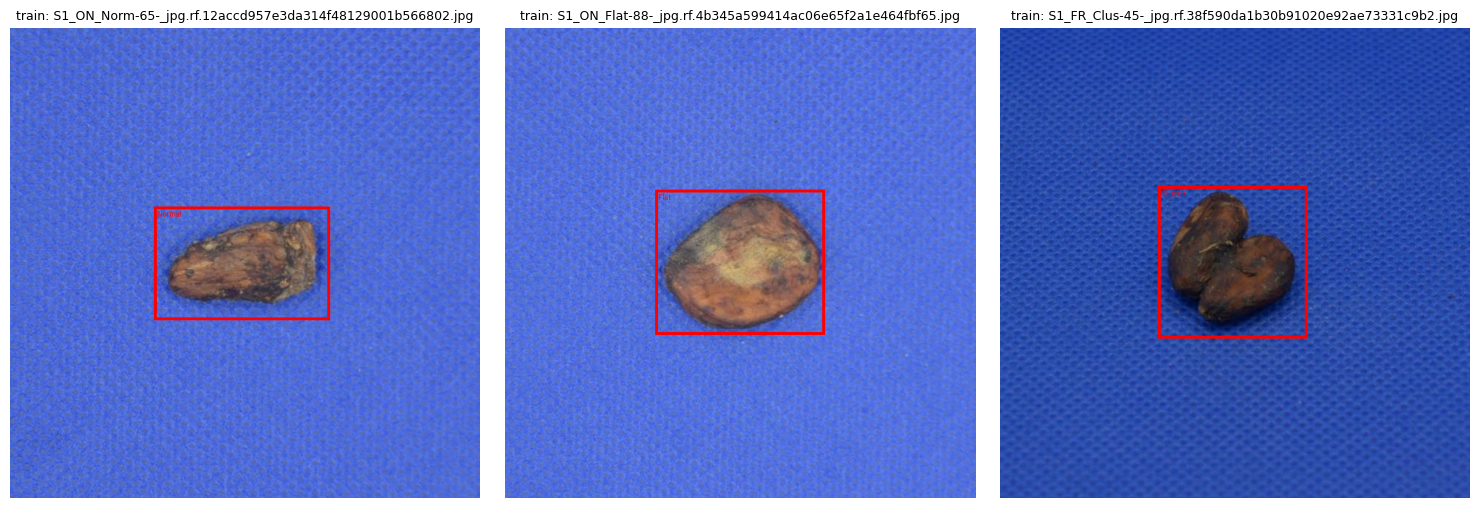

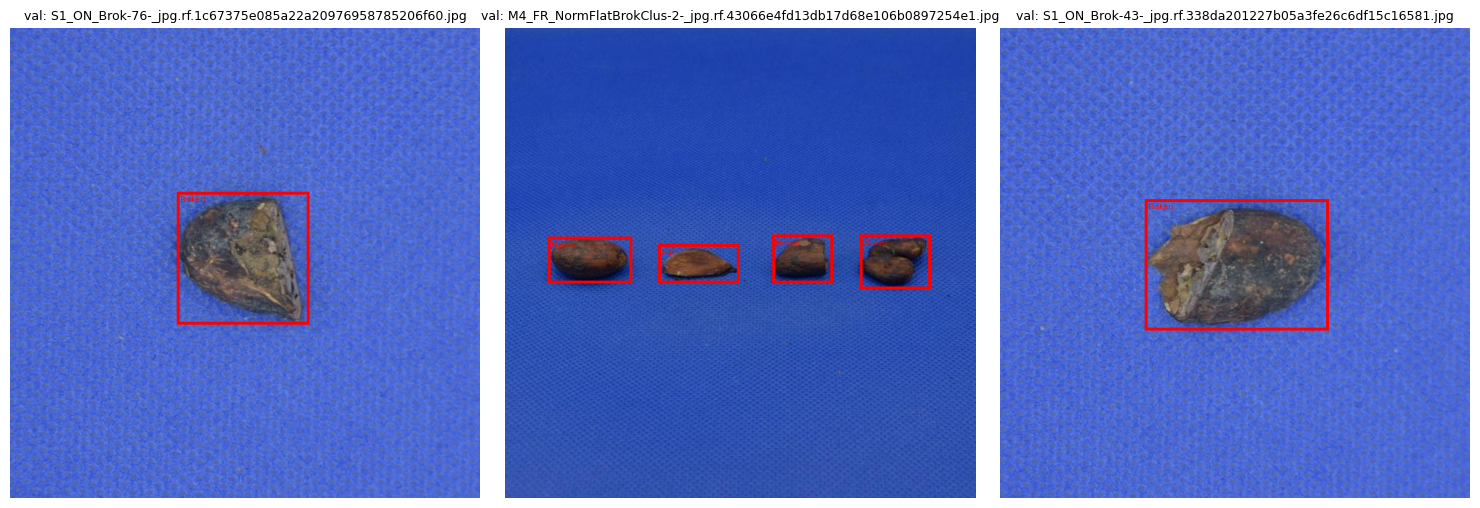

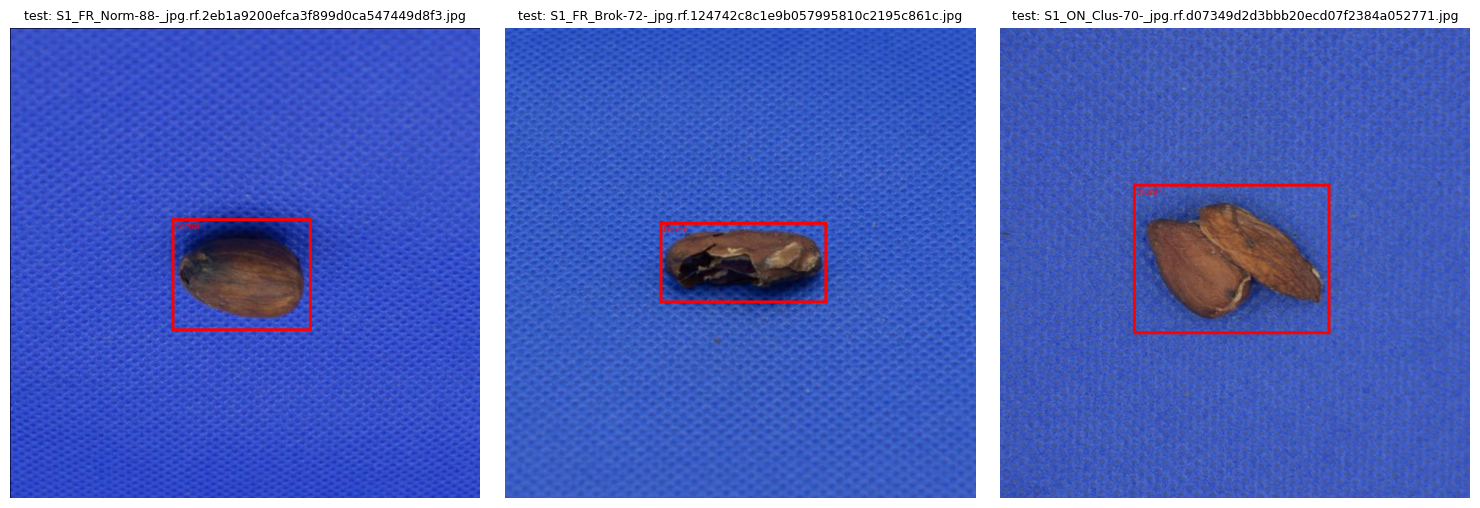

In [ ]:
def draw_sample_records(records, n=3, seed=SEED, title=""):
    rng = random.Random(seed)
    sample = rng.sample(records, k=min(n, len(records)))
    fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]
    for ax, r in zip(axes, sample):
        im = Image.open(r["file_path"]).convert("RGB")
        draw = ImageDraw.Draw(im)
        for a in r["anns"]:
            x, y, w, h = a["bbox"]
            draw.rectangle([x, y, x + w, y + h], outline="red", width=4)
            draw.text((x + 4, y + 4), cat_id_to_name[a["category_id"]], fill="red")
        ax.imshow(im)
        ax.set_title(f"{title}: {r['file_name']}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for split_name in ["train", "val", "test"]:
    draw_sample_records(splits[split_name], n=3, title=split_name)


## 10. Fixed Experimental Settings

In [ ]:
FIXED_SETTINGS = {
    "random_seed": SEED,
    "train_split_pct": 80,
    "val_split_pct": 10,
    "test_split_pct": 10,
    "target_resolution": 640,       # cross-experiment target (see §2 note)
    "actual_model_resolution": 320,  # native/technically-supported resolution for this architecture
    "epochs": 50,
    "batch_size": BATCH_SIZE,
    "confidence_threshold": 0.25,
    "iou_threshold": 0.50,
}

# MobileNet-SSDv3 (torchvision SSDLite320-MobileNetV3-Large) specific hyperparameters.
SSD_HYPERPARAMS = {
    "architecture": "ssdlite320_mobilenet_v3_large",
    "backbone_pretrained": "MobileNet_V3_Large_Weights.IMAGENET1K_V1",
    "detection_head_pretrained": False,  # randomly initialized for the new 4-class problem
    "optimizer": "SGD",
    "lr0": 0.005,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "lr_scheduler": "CosineAnnealingLR",
    "score_thresh_train_default": 0.01,   # torchvision default used internally during training
    "nms_thresh": 0.50,                    # matches the fixed IoU threshold used for evaluation
    "detections_per_img": 100,
    "augmentation": "none beyond torchvision's built-in normalization/resize (kept minimal for a fair, "
                     "documented comparison; no custom mosaic/color-jitter pipeline was added)",
}

print("Fixed cross-experiment settings:")
for k, v in FIXED_SETTINGS.items():
    print(f"  {k}: {v}")
print("\nMobileNet-SSDv3 (SSDLite320-MobileNetV3-Large) specific hyperparameters:")
for k, v in SSD_HYPERPARAMS.items():
    print(f"  {k}: {v}")


Fixed cross-experiment settings:
  random_seed: 42
  train_split_pct: 80
  val_split_pct: 10
  test_split_pct: 10
  target_resolution: 640
  actual_model_resolution: 320
  epochs: 50
  batch_size: 16
  confidence_threshold: 0.25
  iou_threshold: 0.5

MobileNet-SSDv3 (SSDLite320-MobileNetV3-Large) specific hyperparameters:
  architecture: ssdlite320_mobilenet_v3_large
  backbone_pretrained: MobileNet_V3_Large_Weights.IMAGENET1K_V1
  detection_head_pretrained: False
  optimizer: SGD
  lr0: 0.005
  momentum: 0.9
  weight_decay: 0.0005
  lr_scheduler: CosineAnnealingLR
  score_thresh_train_default: 0.01
  nms_thresh: 0.5
  detections_per_img: 100
  augmentation: none beyond torchvision's built-in normalization/resize (kept minimal for a fair, documented comparison; no custom mosaic/color-jitter pipeline was added)


## 11. Build the Model

In [ ]:
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models import MobileNet_V3_Large_Weights

set_global_seed(SEED)

model = ssdlite320_mobilenet_v3_large(
    weights=None,  # no COCO-pretrained detection head (that head is specific to COCO's 91 classes)
    weights_backbone=MobileNet_V3_Large_Weights.IMAGENET1K_V1,  # ImageNet-pretrained MobileNetV3-Large backbone
    num_classes=NUM_CLASSES,
    nms_thresh=SSD_HYPERPARAMS["nms_thresh"],
    detections_per_img=SSD_HYPERPARAMS["detections_per_img"],
)
model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 145MB/s]


Total parameters    : 3,758,900
Trainable parameters: 3,758,900


## 12. Train MobileNet-SSDv3

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=SSD_HYPERPARAMS["lr0"],
                             momentum=SSD_HYPERPARAMS["momentum"],
                             weight_decay=SSD_HYPERPARAMS["weight_decay"])
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FIXED_SETTINGS["epochs"])

def run_train_epoch(loader):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

@torch.no_grad()
def run_val_loss(loader):
    # torchvision detection models only compute the loss dict while in train() mode; we keep
    # train() (for the loss heads to run) but disable gradients so weights are not updated.
    model.train()
    total_loss = 0.0
    n_batches = 0
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

EPOCHS = FIXED_SETTINGS["epochs"]
history = {"epoch": [], "train_loss": [], "val_loss": []}

print(f"Training for {EPOCHS} epochs (batch size {BATCH_SIZE}, imgsz {FIXED_SETTINGS['actual_model_resolution']})...\n")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = run_train_epoch(train_loader)
    val_loss = run_val_loss(val_loader)
    lr_scheduler.step()
    dt = time.time() - t0
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch:3d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | {dt:.1f}s")

RUN_DIR = WORK_DIR / "runs" / "mobilenet_ssdv3_cacao"
RUN_DIR.mkdir(parents=True, exist_ok=True)
BEST_WEIGHTS = RUN_DIR / "mobilenet_ssdv3_cacao_best.pt"
torch.save(model.state_dict(), BEST_WEIGHTS)
print(f"\nTraining complete. Weights saved to: {BEST_WEIGHTS}")

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "training_history.csv", index=False)


Training for 50 epochs (batch size 16, imgsz 320)...

Epoch   1/50 | train_loss=4.5836 | val_loss=2.3842 | 38.9s
Epoch   2/50 | train_loss=1.9714 | val_loss=1.7163 | 36.0s
Epoch   3/50 | train_loss=1.5212 | val_loss=1.3904 | 36.4s
Epoch   4/50 | train_loss=1.2613 | val_loss=1.2953 | 39.1s
Epoch   5/50 | train_loss=1.0833 | val_loss=1.1902 | 36.3s
Epoch   6/50 | train_loss=0.9877 | val_loss=1.0932 | 37.0s
Epoch   7/50 | train_loss=0.8440 | val_loss=1.2109 | 39.4s
Epoch   8/50 | train_loss=0.7621 | val_loss=1.0027 | 37.1s
Epoch   9/50 | train_loss=0.6741 | val_loss=0.9782 | 37.8s
Epoch  10/50 | train_loss=0.6161 | val_loss=0.9582 | 36.0s
Epoch  11/50 | train_loss=0.5556 | val_loss=0.9520 | 39.1s
Epoch  12/50 | train_loss=0.5022 | val_loss=0.9955 | 39.4s
Epoch  13/50 | train_loss=0.4319 | val_loss=0.9064 | 38.9s
Epoch  14/50 | train_loss=0.3825 | val_loss=0.9542 | 38.9s
Epoch  15/50 | train_loss=0.3520 | val_loss=0.9326 | 37.6s
Epoch  16/50 | train_loss=0.3301 | val_loss=0.8952 | 38.9s
Ep

### Training Curves

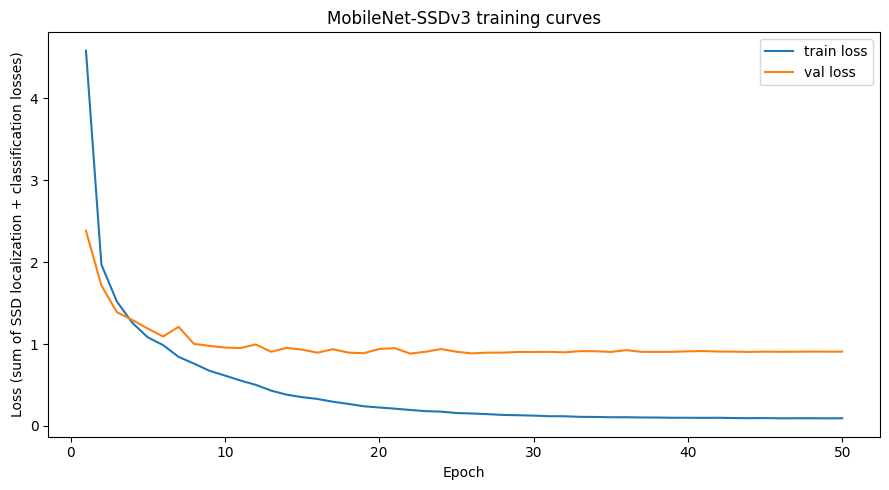

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (sum of SSD localization + classification losses)")
ax.set_title("MobileNet-SSDv3 training curves")
ax.legend()
plt.tight_layout()
plt.show()


## 13. Evaluation Utilities (mAP + Precision/Recall)

`torchmetrics`'s `MeanAveragePrecision` implements the standard COCO-style protocol for **mAP@0.5** and **mAP@0.5:0.95** (threshold-free). Precision and Recall are reported at the fixed operating point required by the protocol (confidence ≥ 0.25, IoU ≥ 0.50) via a direct greedy matching between predictions and ground truth, computed identically for every model in this study.

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

@torch.no_grad()
def get_predictions(loader, score_thresh=0.0):
    model.eval()
    all_preds, all_targets, all_records = [], [], []
    for images, targets in loader:
        images_dev = [img.to(device) for img in images]
        outputs = model(images_dev)
        for out, tgt in zip(outputs, targets):
            keep = out["scores"] >= score_thresh
            pred = {
                "boxes": out["boxes"][keep].cpu(),
                "scores": out["scores"][keep].cpu(),
                "labels": out["labels"][keep].cpu(),
            }
            gt = {"boxes": tgt["boxes"].cpu(), "labels": tgt["labels"].cpu()}
            all_preds.append(pred)
            all_targets.append(gt)
    return all_preds, all_targets

def compute_map(preds, targets):
    metric = MeanAveragePrecision(iou_type="bbox", box_format="xyxy")
    metric.update(preds, targets)
    result = metric.compute()
    return {
        "map50": float(result["map_50"]),
        "map50_95": float(result["map"]),
    }

def iou_xyxy(box1, box2):
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    a1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    a2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

def compute_precision_recall(preds, targets, conf_thresh=0.25, iou_thresh=0.50):
    tp = fp = fn = 0
    for pred, gt in zip(preds, targets):
        keep = pred["scores"] >= conf_thresh
        p_boxes = pred["boxes"][keep].tolist()
        p_labels = pred["labels"][keep].tolist()
        p_scores = pred["scores"][keep].tolist()
        order = sorted(range(len(p_scores)), key=lambda i: -p_scores[i])

        g_boxes = gt["boxes"].tolist()
        g_labels = gt["labels"].tolist()
        matched_gt = [False] * len(g_boxes)

        for i in order:
            pb, pl = p_boxes[i], p_labels[i]
            best_iou, best_j = 0.0, -1
            for j, (gb, gl) in enumerate(zip(g_boxes, g_labels)):
                if matched_gt[j] or gl != pl:
                    continue
                iou = iou_xyxy(pb, gb)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= iou_thresh and best_j >= 0:
                matched_gt[best_j] = True
                tp += 1
            else:
                fp += 1
        fn += matched_gt.count(False)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall, tp, fp, fn

print("Evaluation utilities defined.")


Evaluation utilities defined.


## 14. Evaluation on the Test Set (10% held-out)

In [ ]:
test_preds, test_targets = get_predictions(test_loader, score_thresh=0.0)  # keep all, threshold applied per-metric

map_result = compute_map(test_preds, test_targets)
precision, recall, tp, fp, fn = compute_precision_recall(
    test_preds, test_targets,
    conf_thresh=FIXED_SETTINGS["confidence_threshold"],
    iou_thresh=FIXED_SETTINGS["iou_threshold"],
)
map50 = map_result["map50"]
map50_95 = map_result["map50_95"]

print("=== Detection Accuracy (test set) ===")
print(f"Precision    : {precision:.4f}  (TP={tp}, FP={fp}, FN={fn})")
print(f"Recall       : {recall:.4f}")
print(f"mAP@0.5      : {map50:.4f}")
print(f"mAP@0.5:0.95 : {map50_95:.4f}")


=== Detection Accuracy (test set) ===
Precision    : 0.9034  (TP=346, FP=37, FN=18)
Recall       : 0.9505
mAP@0.5      : 0.9738
mAP@0.5:0.95 : 0.8028


## 15. Inference Speed

In [ ]:
model.eval()
test_records = splits["test"]
n_warmup = 5

with torch.no_grad():
    for r in test_records[:n_warmup]:
        img = TF.to_tensor(Image.open(r["file_path"]).convert("RGB")).to(device)
        _ = model([img])

torch.cuda.synchronize()
per_image_ms = []
with torch.no_grad():
    for r in test_records:
        img = TF.to_tensor(Image.open(r["file_path"]).convert("RGB")).to(device)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model([img])
        torch.cuda.synchronize()
        per_image_ms.append((time.perf_counter() - t0) * 1000.0)

avg_inference_ms = float(np.mean(per_image_ms))
fps = 1000.0 / avg_inference_ms if avg_inference_ms > 0 else float("nan")

print(f"Images timed           : {len(test_records)}")
print(f"Average inference time : {avg_inference_ms:.2f} ms/image (single-image forward pass, GPU-synchronized)")
print(f"Throughput              : {fps:.2f} FPS")


Images timed           : 240
Average inference time : 14.76 ms/image (single-image forward pass, GPU-synchronized)
Throughput              : 67.73 FPS


## 16. Computational Efficiency and Model Size

In [ ]:
model_size_mb = os.path.getsize(BEST_WEIGHTS) / (1024 ** 2)

gflops = None
try:
    from fvcore.nn import FlopCountAnalysis
    model.eval()
    dummy = TF.to_tensor(Image.open(test_records[0]["file_path"]).convert("RGB")).to(device)
    flops = FlopCountAnalysis(model, ([dummy],))
    flops.unsupported_ops_warnings(False)
    gflops = flops.total() / 1e9
except Exception as e:
    print("FLOPs could not be measured with fvcore for this model (reporting as not measurable):", e)

torch.cuda.reset_peak_memory_stats()
with torch.no_grad():
    _ = model([TF.to_tensor(Image.open(test_records[0]["file_path"]).convert("RGB")).to(device)])
peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

print("=== Computational Efficiency & Model Size ===")
print(f"Parameters           : {n_params:,}")
print(f"GFLOPs (at {FIXED_SETTINGS['actual_model_resolution']}x{FIXED_SETTINGS['actual_model_resolution']}): "
      f"{gflops:.2f}" if gflops is not None else "GFLOPs                : not measurable in this environment")
print(f"Model file size       : {model_size_mb:.2f} MB  ({BEST_WEIGHTS.name})")
print(f"Peak GPU memory (inference, single image): {peak_mem_mb:.1f} MB")


/usr/local/lib/python3.13/dist-packages/torchvision/ops/boxes.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes_x = torch.min(boxes_x, torch.tensor(width, dtype=boxes.dtype, device=boxes.device))
/usr/local/lib/python3.13/dist-packages/torchvision/ops/boxes.py:176: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes_y = torch.min(boxes_y, torch.tensor(height, dtype=boxes.dtype, device=boxes.device))
/usr/local/lib/python3.13/dist-packages/torchvision/models/detection/transform.py:308: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


=== Computational Efficiency & Model Size ===
Parameters           : 3,758,900
GFLOPs (at 320x320): 0.52
Model file size       : 14.67 MB  (mobilenet_ssdv3_cacao_best.pt)
Peak GPU memory (inference, single image): 72.9 MB


### Confusion-style Class Breakdown

In [ ]:
per_class_rows = []
for cid, name in zip(used_cat_ids, yolo_classes):
    model_id = coco_id_to_model_id[cid]
    cls_preds, cls_targets = [], []
    for pred, gt in zip(test_preds, test_targets):
        keep_p = pred["labels"] == model_id
        keep_g = gt["labels"] == model_id
        cls_preds.append({"boxes": pred["boxes"][keep_p], "scores": pred["scores"][keep_p], "labels": pred["labels"][keep_p]})
        cls_targets.append({"boxes": gt["boxes"][keep_g], "labels": gt["labels"][keep_g]})
    p, r, tp_c, fp_c, fn_c = compute_precision_recall(cls_preds, cls_targets,
                                                        conf_thresh=FIXED_SETTINGS["confidence_threshold"],
                                                        iou_thresh=FIXED_SETTINGS["iou_threshold"])
    per_class_rows.append({"class": name, "precision": p, "recall": r, "TP": tp_c, "FP": fp_c, "FN": fn_c})

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df)


,class,precision,recall,TP,FP,FN
0,Broken,0.941176,0.898876,80,5,9
1,Cluster,0.959596,1.000000,95,4,0
2,Flat,0.854167,0.921348,82,14,7
3,Normal,0.864078,0.978022,89,14,2


## 17. Robustness Evaluation

Same protocol as the YOLOv11n notebook: the test set is perturbed one condition at a time (brightness, contrast, Gaussian noise, ±10° rotation). Rotation recomputes an exact axis-aligned bounding box from the rotated corners (absolute pixel coordinates, matching this framework's box format). The same trained model and the same conf/IoU thresholds are then evaluated on each perturbed copy.

In [ ]:
ROTATION_DEGREES = 10

def rotate_bbox_abs(x1, y1, x2, y2, img_w, img_h, angle_deg):
    cx, cy = img_w / 2.0, img_h / 2.0
    corners = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
    theta = math.radians(-angle_deg)
    rc = []
    for (x, y) in corners:
        rx = cx + (x - cx) * math.cos(theta) - (y - cy) * math.sin(theta)
        ry = cy + (x - cx) * math.sin(theta) + (y - cy) * math.cos(theta)
        rc.append((rx, ry))
    xs = [p[0] for p in rc]; ys = [p[1] for p in rc]
    nx1, nx2 = max(0, min(xs)), min(img_w, max(xs))
    ny1, ny2 = max(0, min(ys)), min(img_h, max(ys))
    return nx1, ny1, nx2, ny2

perturbations = {
    "brightness_down": lambda im: ImageEnhance.Brightness(im).enhance(0.6),
    "brightness_up":   lambda im: ImageEnhance.Brightness(im).enhance(1.4),
    "contrast_down":   lambda im: ImageEnhance.Contrast(im).enhance(0.6),
    "contrast_up":     lambda im: ImageEnhance.Contrast(im).enhance(1.4),
    "gaussian_noise":  lambda im: Image.fromarray(
        np.clip(np.array(im).astype(np.float32) + np.random.default_rng(SEED).normal(0, 15, np.array(im).shape),
                0, 255).astype(np.uint8)),
    "rotation_10deg":  lambda im: im.rotate(ROTATION_DEGREES, resample=Image.BILINEAR, expand=False, fillcolor=(114, 114, 114)),
}
rotate_flags = {k: (k == "rotation_10deg") for k in perturbations}

@torch.no_grad()
def evaluate_perturbation(name, transform_fn, rotate):
    model.eval()
    preds, targets = [], []
    for r in test_records:
        im = Image.open(r["file_path"]).convert("RGB")
        w, h = im.size
        new_im = transform_fn(im)
        img_t = TF.to_tensor(new_im).to(device)
        out = model([img_t])[0]

        boxes, labels = [], []
        for a in r["anns"]:
            x, y, bw, bh = a["bbox"]
            x1, y1, x2, y2 = x, y, x + bw, y + bh
            if rotate:
                x1, y1, x2, y2 = rotate_bbox_abs(x1, y1, x2, y2, w, h, ROTATION_DEGREES)
            boxes.append([x1, y1, x2, y2])
            labels.append(coco_id_to_model_id[a["category_id"]])
        boxes_t = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))
        labels_t = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        preds.append({"boxes": out["boxes"].cpu(), "scores": out["scores"].cpu(), "labels": out["labels"].cpu()})
        targets.append({"boxes": boxes_t, "labels": labels_t})
    return preds, targets

robustness_rows = [{
    "perturbation": "baseline (clean test set)",
    "precision": precision, "recall": recall, "mAP50": map50, "mAP50_95": map50_95,
}]

for name, fn in perturbations.items():
    preds, targets = evaluate_perturbation(name, fn, rotate_flags[name])
    p, r, *_ = compute_precision_recall(preds, targets,
                                         conf_thresh=FIXED_SETTINGS["confidence_threshold"],
                                         iou_thresh=FIXED_SETTINGS["iou_threshold"])
    m = compute_map(preds, targets)
    robustness_rows.append({
        "perturbation": name, "precision": p, "recall": r,
        "mAP50": m["map50"], "mAP50_95": m["map50_95"],
    })
    print(f"Evaluated perturbation: {name}")

robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df)


Evaluated perturbation: brightness_down
Evaluated perturbation: brightness_up
Evaluated perturbation: contrast_down
Evaluated perturbation: contrast_up
Evaluated perturbation: gaussian_noise
Evaluated perturbation: rotation_10deg


,perturbation,precision,recall,mAP50,mAP50_95
0,baseline (clean test set),0.903394,0.950549,0.973809,0.802845
1,brightness_down,0.711712,0.868132,0.904077,0.694357
2,brightness_up,0.761229,0.884615,0.926170,0.729868
3,contrast_down,0.707763,0.851648,0.914273,0.708040
4,contrast_up,0.800475,0.925824,0.949047,0.764861
5,gaussian_noise,0.750000,0.906593,0.931911,0.735374
6,rotation_10deg,0.721461,0.868132,0.891518,0.449173


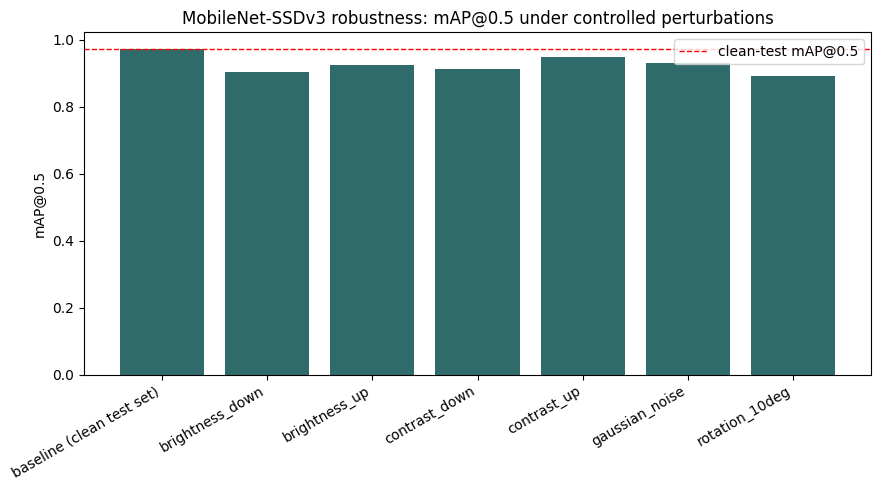

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(robustness_df["perturbation"], robustness_df["mAP50"], color="#2f6b6b")
ax.axhline(map50, color="red", linestyle="--", linewidth=1, label="clean-test mAP@0.5")
ax.set_ylabel("mAP@0.5")
ax.set_title("MobileNet-SSDv3 robustness: mAP@0.5 under controlled perturbations")
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


## 18. Reproducibility Record

In [ ]:
import sklearn
reproducibility_record = {
    "random_seed": SEED,
    "dataset": {
        "source_zip": DATASET_ZIP,
        "roboflow_version": 12,
        "total_images": len(pool),
        "split_manifest": str(manifest_path) if EXTERNAL_SPLIT_MANIFEST is None else EXTERNAL_SPLIT_MANIFEST,
        "split_sizes": dict(split_counts),
        "classes": yolo_classes,
    },
    "model": {
        "name": "MobileNet-SSDv3",
        "implementation": "torchvision.models.detection.ssdlite320_mobilenet_v3_large",
        "backbone_pretrained_weights": SSD_HYPERPARAMS["backbone_pretrained"],
        "best_weights_path": str(BEST_WEIGHTS),
    },
    "software_versions": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "cuda": torch.version.cuda,
        "torchmetrics": torchmetrics.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "hardware": {"gpu_name": gpu_name},
    "fixed_settings": FIXED_SETTINGS,
    "ssd_hyperparameters": SSD_HYPERPARAMS,
}

repro_path = WORK_DIR / "reproducibility_record.json"
with open(repro_path, "w") as f:
    json.dump(reproducibility_record, f, indent=2, default=str)

print(json.dumps(reproducibility_record, indent=2, default=str))


{
  "random_seed": 42,
  "dataset": {
    "source_zip": "Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip",
    "roboflow_version": 12,
    "total_images": 2400,
    "split_manifest": "/content/cacao_mobilenetssdv3/dataset_split_seed42.json",
    "split_sizes": {
      "train": 1920,
      "val": 240,
      "test": 240
    },
    "classes": [
      "Broken",
      "Cluster",
      "Flat",
      "Normal"
    ]
  },
  "model": {
    "name": "MobileNet-SSDv3",
    "implementation": "torchvision.models.detection.ssdlite320_mobilenet_v3_large",
    "backbone_pretrained_weights": "MobileNet_V3_Large_Weights.IMAGENET1K_V1",
    "best_weights_path": "/content/cacao_mobilenetssdv3/runs/mobilenet_ssdv3_cacao/mobilenet_ssdv3_cacao_best.pt"
  },
  "software_versions": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "cuda": "12.8",
    "torchmetrics": "1.9.0",
    "scikit_learn": "1.6.1"
  },
  "hardware": {
    "gpu_name": "Tesla T4"
  },
  "fixe

## 19. Final Results Table — Five Evaluation Criteria

In [ ]:
final_rows = [
    ("1. Detection Accuracy", "Precision (test set)", f"{precision:.4f}"),
    ("1. Detection Accuracy", "Recall (test set)", f"{recall:.4f}"),
    ("1. Detection Accuracy", "mAP@0.5", f"{map50:.4f}"),
    ("1. Detection Accuracy", "mAP@0.5:0.95", f"{map50_95:.4f}"),
    ("2. Inference Speed", "Avg. inference time / image", f"{avg_inference_ms:.2f} ms"),
    ("2. Inference Speed", "Throughput", f"{fps:.2f} FPS"),
    ("3. Computational Efficiency", "Parameters", f"{n_params:,}"),
    ("3. Computational Efficiency", "GFLOPs", f"{gflops:.2f}" if gflops is not None else "not measurable"),
    ("3. Computational Efficiency", "Peak GPU memory (inference)", f"{peak_mem_mb:.1f} MB"),
    ("4. Model Size", "File size", f"{model_size_mb:.2f} MB"),
    ("4. Model Size", "Parameters", f"{n_params:,}"),
    ("5. Robustness", "Worst-case mAP@0.5 (any perturbation)",
     f"{robustness_df[robustness_df['perturbation'] != 'baseline (clean test set)']['mAP50'].min():.4f}"),
    ("5. Robustness", "Mean mAP@0.5 across all perturbations",
     f"{robustness_df[robustness_df['perturbation'] != 'baseline (clean test set)']['mAP50'].mean():.4f}"),
]
final_df = pd.DataFrame(final_rows, columns=["Criterion", "Indicator", "Value"])
final_csv_path = WORK_DIR / "mobilenet_ssdv3_final_results.csv"
final_df.to_csv(final_csv_path, index=False)

pd.set_option("display.max_colwidth", None)
display(final_df)
print(f"\nSaved to: {final_csv_path}")
print("All values above were measured directly in this notebook run; none were fabricated or estimated.")


,Criterion,Indicator,Value
0,1. Detection Accuracy,Precision (test set),0.9034
1,1. Detection Accuracy,Recall (test set),0.9505
2,1. Detection Accuracy,mAP@0.5,0.9738
3,1. Detection Accuracy,mAP@0.5:0.95,0.8028
4,2. Inference Speed,Avg. inference time / image,14.76 ms
5,2. Inference Speed,Throughput,67.73 FPS
6,3. Computational Efficiency,Parameters,"3,758,900"
7,3. Computational Efficiency,GFLOPs,0.52
8,3. Computational Efficiency,Peak GPU memory (inference),72.9 MB
9,4. Model Size,File size,14.67 MB



Saved to: /content/cacao_mobilenetssdv3/mobilenet_ssdv3_final_results.csv
All values above were measured directly in this notebook run; none were fabricated or estimated.
